# Trade-size distribution

Load every swap, value each in USD via the hourly price, and build the pooled
trade-size distribution. Its quantiles are the reference trade sizes used by
`arbitrage_index.ipynb`. Parameters come from `arblib.config.STUDY`.

In [ ]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, sizing, preprocessing, plotting
from arblib.config import STUDY as S

dfs = data_io.load_pool_csvs(S.swaps_dir)
swaps = sizing.pooled_swaps(dfs)
prices = data_io.load_usd_prices(S.prices_path)

## 1. Verify token identity ↔ decimals

In [2]:
preprocessing.verify_token_decimals(swaps, S.token0, S.token1)

0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 -> 6 decimals
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 -> 18 decimals

OK: token0 (6 dp), token1 (18 dp) consistent across all pools.


## 2. Human + USD amounts

In [3]:
swaps = sizing.add_usd_amounts(swaps, prices)
swaps[["hour", "amount0_h", "amount0_usd", "amount1_h", "amount1_usd"]].head()

,hour,amount0_h,amount0_usd,amount1_h,amount1_usd
0,2025-12-31 15:00:00,-999.266400,-999.556437,0.334198,995.732773
1,2025-12-31 15:00:00,33.925490,33.935337,-0.011346,-33.803641
2,2025-12-31 15:00:00,13936.469654,13940.514714,-4.658615,-13880.204392
3,2025-12-31 15:00:00,-107.703773,-107.735034,0.036026,107.337084
4,2025-12-31 15:00:00,-154.244910,-154.289680,0.051582,153.687553


## 3. Split by direction (the in-leg of each swap)

In [4]:
x_in, y_in = sizing.split_in_legs(swaps)

Kept 1272 of 1306 swaps after dust filter
token0-in: 657 swaps | token1-in: 615 swaps


## 4. Trade-size distributions (per leg)

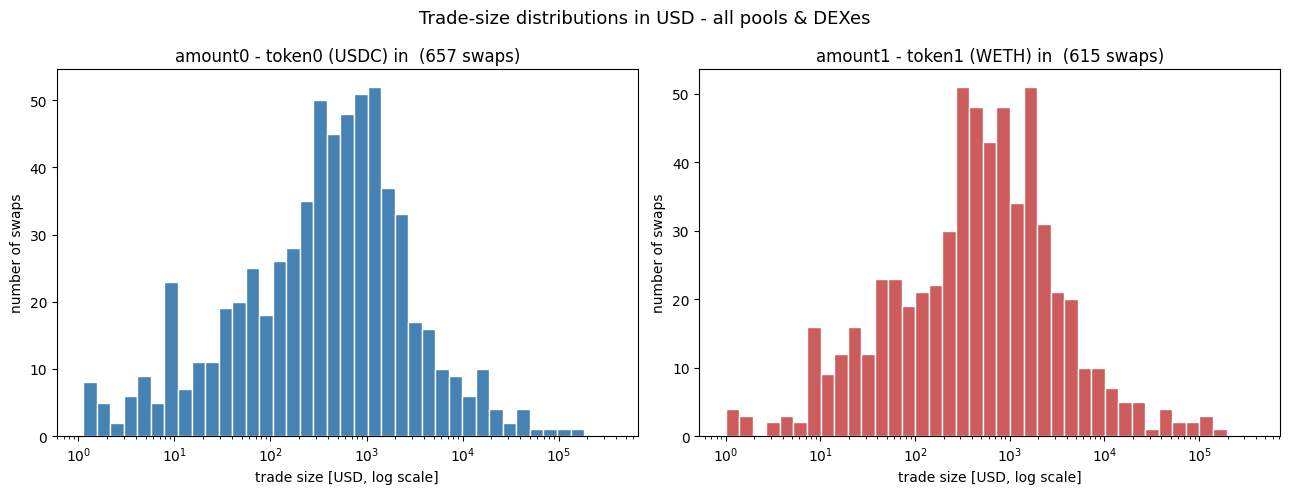

In [5]:
plotting.plot_trade_size_distributions(x_in, y_in, S.token0.symbol, S.token1.symbol)

## 5. Global distribution & reference quantiles

0.2      63.195045
0.4     313.031954
0.6     740.312922
0.8    1857.293128
dtype: float64


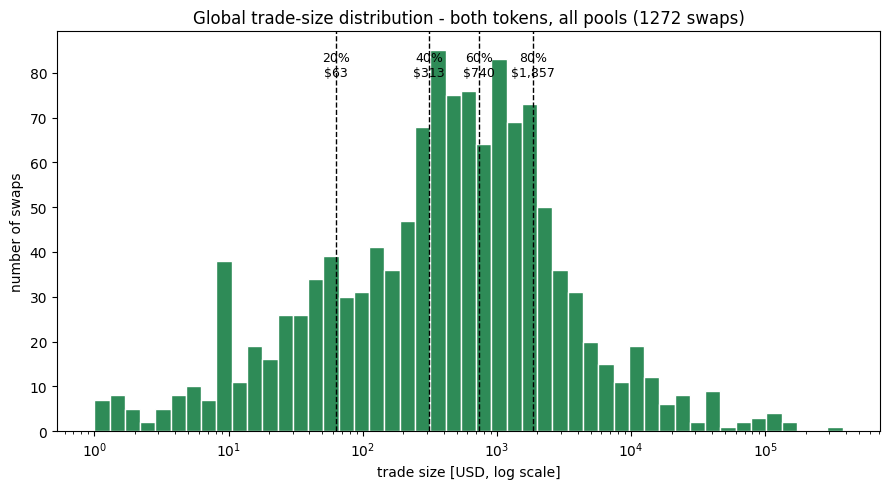

In [6]:
trade_sizes = sizing.pooled_trade_sizes(x_in, y_in)
quantiles = sizing.trade_size_quantiles(trade_sizes, [0.2, 0.4, 0.6, 0.8])
print(quantiles)
plotting.plot_global_trade_size(trade_sizes, quantiles)

## 6. Save the reference trade sizes

In [7]:
data_io.save_quantiles(quantiles, S.quantiles_path)

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/trade_size_quantiles.csv
